# Stage 3. Conjunctiva Segmentation

Notebook ini melatih U-Net pada foto mata utuh Eyes-Defy untuk memprediksi mask konjungtiva palpebral, lalu mengevaluasi kualitas segmentasi memakai Dice dan IoU serta menampilkan contoh overlay. Segmentasi ini menjadi jembatan dari citra mentah menuju region of interest pada mode capture di lapangan.

## Environment Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent.parent))

import matplotlib.pyplot as plt
import torch
from PIL import Image

from configs import paths
from src.common import manifest as manifest_utils
from src.sites.conjunctiva import data, segmentation

manifest = manifest_utils.assign_stratified_split(data.build_manifest(save=False))
print("device", "cuda" if torch.cuda.is_available() else "cpu")

Eyes-Defy Italy melewati 2 folder tanpa metadata atau file lengkap: [93, 95]
Eyes-Defy India melewati 1 folder tanpa metadata atau file lengkap: [7]
device cuda


## Segmentation Datasets

Hanya baris Eyes-Defy yang dipakai karena memuat foto mata utuh dan mask palpebral. Foto dimuat dengan koreksi orientasi EXIF agar sejajar dengan mask.

In [2]:
train_ds, val_ds = segmentation.build_datasets(manifest, size=320)
print("train", len(train_ds), "val", len(val_ds))

train 151 val 64


## Train U-Net

Melatih U-Net dengan encoder ResNet34 pralatih ImageNet memakai kombinasi Dice loss dan binary cross entropy. Checkpoint terbaik disimpan berdasarkan Dice validasi.

In [3]:
result = segmentation.train_unet(
    manifest,
    size=320,
    epochs=25,
    batch_size=8,
    artifacts_dir=paths.artifacts_dir("conjunctiva"),
    output_dir=paths.outputs_dir("conjunctiva"),
)
print("best val dice", round(result["metrics"]["best_val_dice"], 4))
print("final val iou", round(result["metrics"]["final_val_iou"], 4))

epoch 01 train_loss 1.3516 val_dice 0.3259 val_iou 0.2129


epoch 02 train_loss 0.9579 val_dice 0.7622 val_iou 0.6226


epoch 03 train_loss 0.6750 val_dice 0.7730 val_iou 0.6357


epoch 04 train_loss 0.4758 val_dice 0.7902 val_iou 0.6601


epoch 05 train_loss 0.3738 val_dice 0.7658 val_iou 0.6380


...

epoch 21 train_loss 0.2101 val_dice 0.8252 val_iou 0.7087


epoch 22 train_loss 0.2149 val_dice 0.8381 val_iou 0.7271


epoch 23 train_loss 0.1992 val_dice 0.8476 val_iou 0.7405


epoch 24 train_loss 0.1993 val_dice 0.8422 val_iou 0.7326


epoch 25 train_loss 0.1922 val_dice 0.8282 val_iou 0.7128
best val dice 0.8508
final val iou 0.7128


## Training Curves

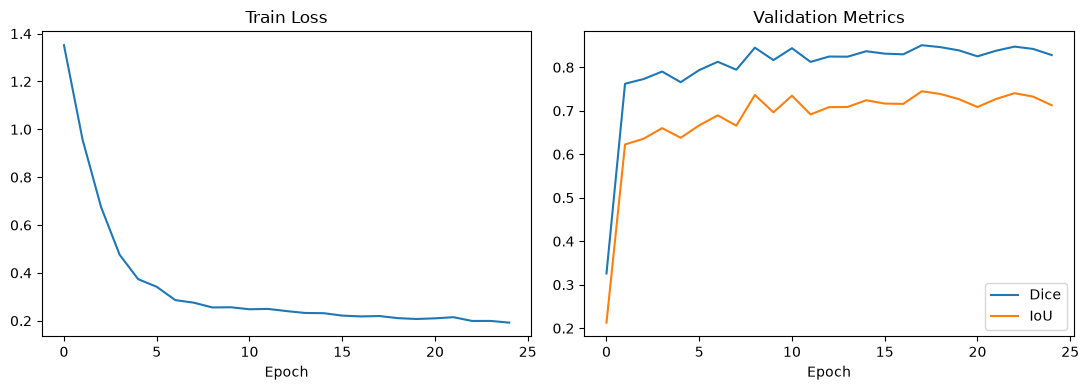

In [4]:
history = result["history"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history["train_loss"])
axes[0].set_title("Train Loss")
axes[0].set_xlabel("Epoch")
axes[1].plot(history["val_dice"], label="Dice")
axes[1].plot(history["val_iou"], label="IoU")
axes[1].set_title("Validation Metrics")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
plt.show()

## Prediction Overlays

Overlay membandingkan citra, mask acuan, dan prediksi model pada data validasi.

overlays saved to /home/praktikan/projects/Azril/hemavision/outputs/conjunctiva/segmentation_overlays.png


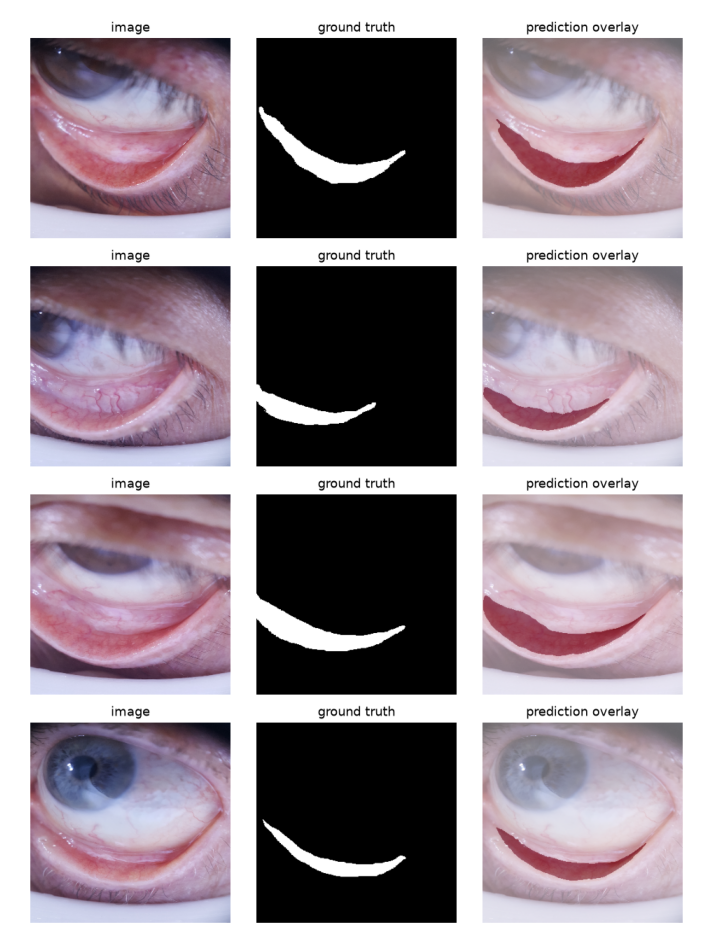

In [5]:
overlay_path = segmentation.save_overlays(
    result["model"], val_ds, count=4, output_dir=paths.outputs_dir("conjunctiva")
)
print("overlays saved to", overlay_path)
plt.figure(figsize=(9, 12))
plt.imshow(Image.open(overlay_path))
plt.axis("off")
plt.show()